In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#importing dataset
df  = df = pd.read_csv(r'C:\Users\lenovo\Downloads\heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [5]:
#finding no of unique values in columns
print(df['target'].unique())

#calculating no of times unique values in target
print(df['target'].value_counts())

[1 0]
target
1    165
0    138
Name: count, dtype: int64


age
29     1
34     2
35     4
37     2
38     3
39     4
40     3
41    10
42     8
43     8
44    11
45     8
46     7
47     5
48     7
49     5
50     7
51    12
52    13
53     8
54    16
55     8
56    11
57    17
58    19
59    14
60    11
61     8
62    11
63     9
64    10
65     8
66     7
67     9
68     4
69     3
70     4
71     3
74     1
76     1
77     1
Name: count, dtype: int64


Text(0, 0.5, 'counts')

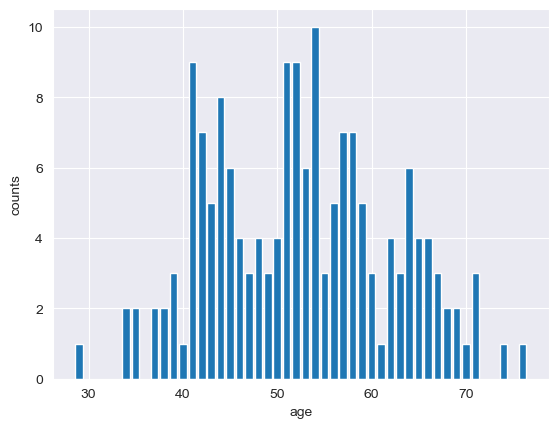

In [7]:
y=df[df['target']==1]


print(df['age'].value_counts().sort_index())
age_counts = y['age'].value_counts().sort_index()

sns.set_style('darkgrid')
plt.bar(age_counts.index,age_counts.values)
plt.xlabel("age")
plt.ylabel("counts")


In [9]:
#checking for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

target
1    165
0    138
Name: count, dtype: int64


<Axes: xlabel='target', ylabel='count'>

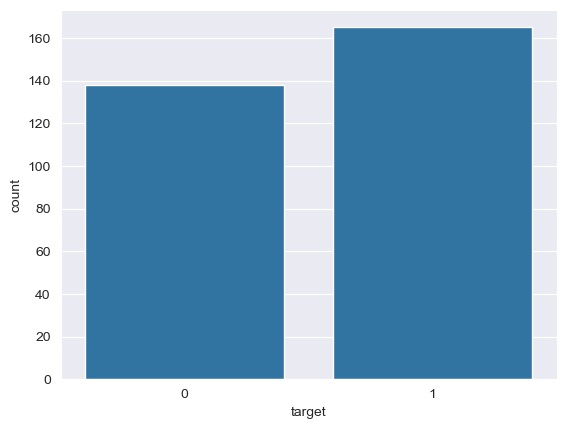

In [13]:
c = df['target'].value_counts()
print(c)
sns.set_style('darkgrid')
sns.countplot(x='target',data = df)

sex
1    207
0     96
Name: count, dtype: int64


<Axes: xlabel='sex', ylabel='count'>

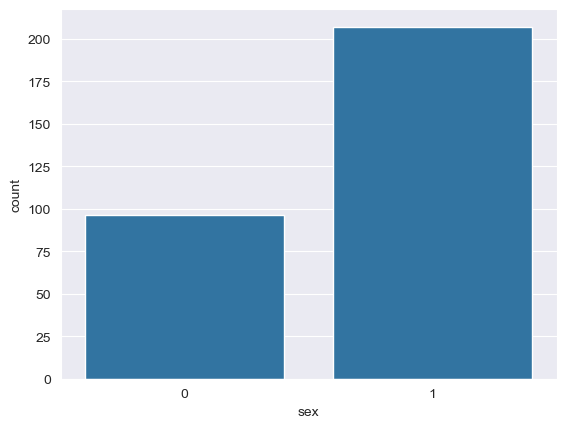

In [15]:
print(df['sex'].value_counts())
sns.set_style('darkgrid')
sns.countplot(x='sex',data = df)

1 age
2 sex
3 cp
4 trestbps
5 chol
6 fbs
7 restecg
8 thalach
9 exang
10 oldpeak
11 slope
12 ca
13 thal
14 target


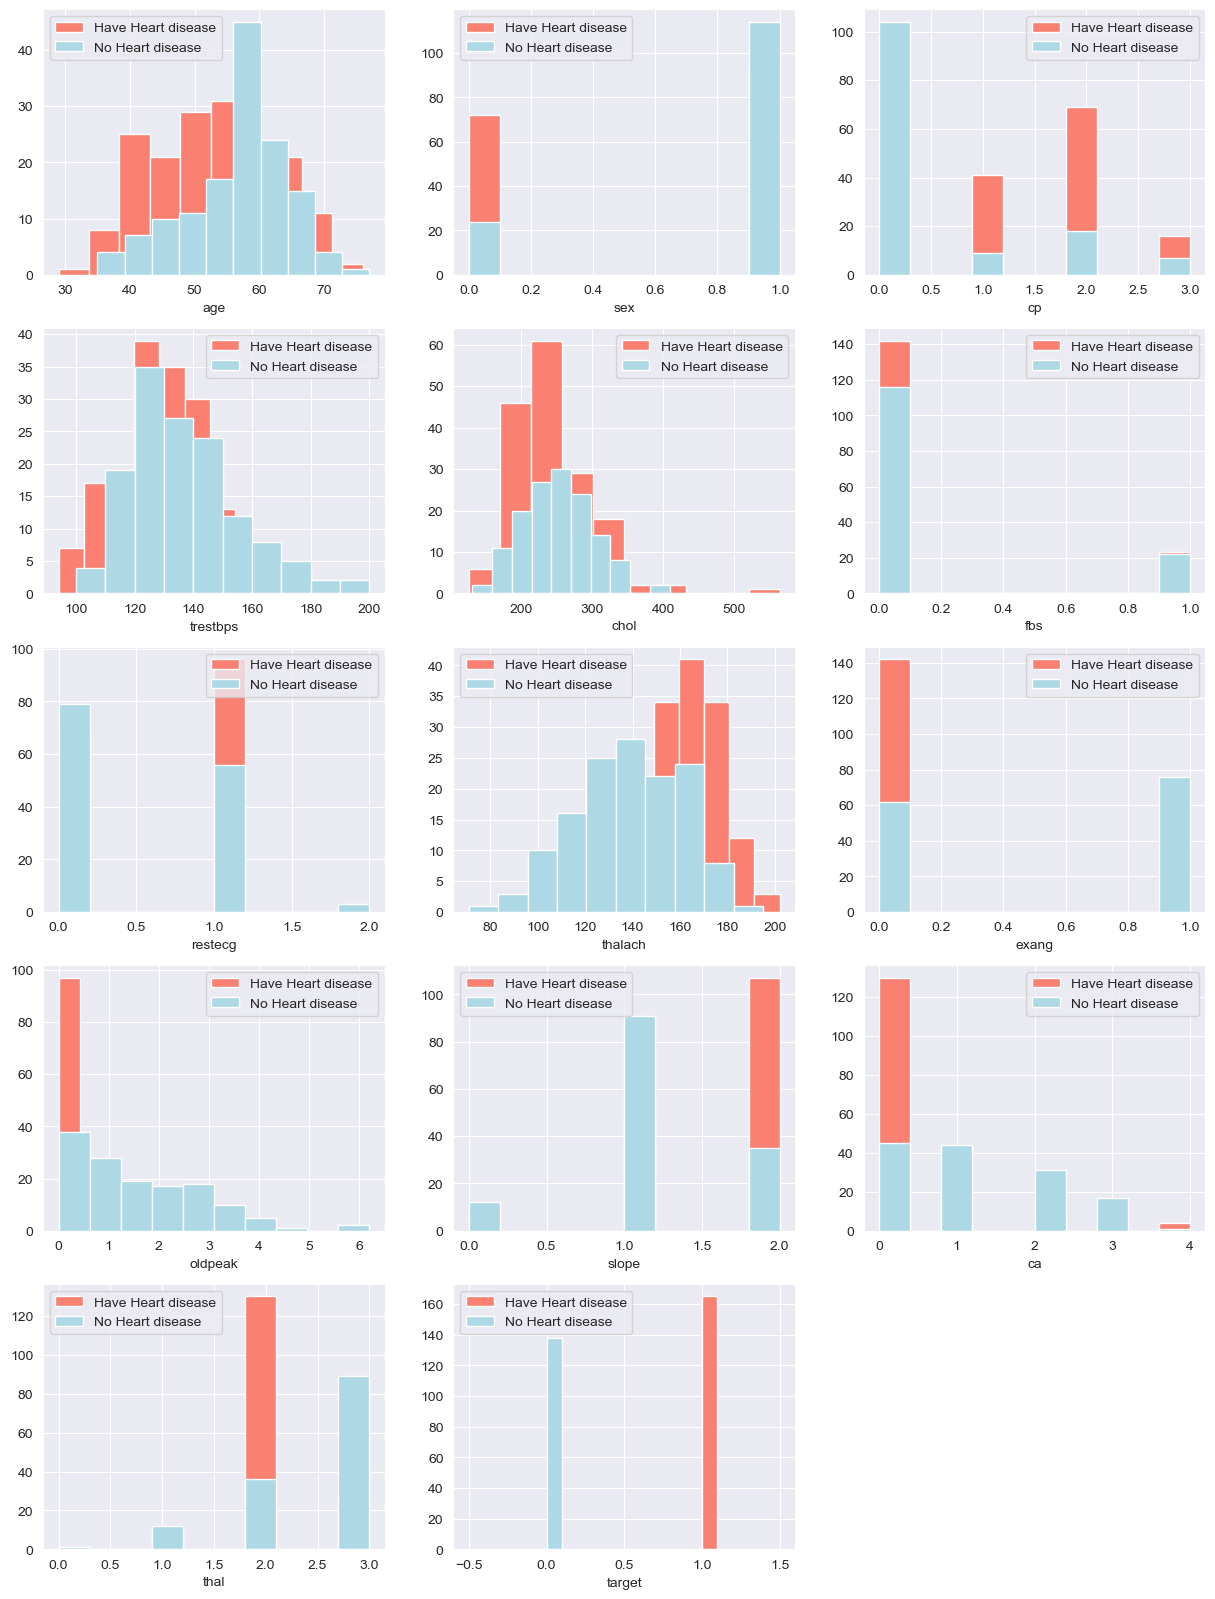

In [17]:
plt.figure(figsize = (15,20))

for i,column in enumerate(df.columns,1):
    print(i,column)
    plt.subplot(5,3,i)
    g = df[df['target']==1][column]
    j = df[df['target']==0][column]
    plt.hist(g,color = 'salmon',label='Have Heart disease')
    plt.hist(j,color = 'lightblue',label='No Heart disease')
    plt.legend()
    plt.xlabel(column)

In [19]:
X = df.drop(columns = 'target')
#X.head()
y = df['target']
#y.head()
print(X)
print(y)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [21]:
from sklearn.model_selection import train_test_split

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 10)

In [25]:
from sklearn.metrics import accuracy_score
#feature engineering - standarization

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
#fit the scaler to the train set, it will learn the parameter
sc.fit(X_train)
#tranform train & test sets
X_train_scaled = sc.transform(X_train)
X_tset_scaled = sc.transform(X_test)
sc.mean_

array([5.42892562e+01, 6.52892562e-01, 9.91735537e-01, 1.31252066e+02,
       2.47392562e+02, 1.57024793e-01, 5.28925620e-01, 1.50309917e+02,
       3.05785124e-01, 9.87190083e-01, 1.39669421e+00, 6.94214876e-01,
       2.26446281e+00])

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score

In [29]:
knn = KNeighborsClassifier(n_neighbors = 7)
dt = DecisionTreeClassifier()
lr =  LogisticRegression(max_iter = 1000)

In [31]:

lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [33]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=7)

In [35]:
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [37]:
y_lr_pred = lr.predict(X_test)
print(y_lr_pred)

[0 1 0 1 0 1 1 1 1 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 0 1
 0 1 0 0 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 0 0 1]


In [39]:
y_knn_pred = knn.predict(X_test)
print(y_knn_pred)

[1 1 1 1 0 1 1 1 1 0 1 0 0 1 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 0 1 0 0 1]


In [41]:
y_dt_pred = dt.predict(X_test)
print(y_dt_pred)

[1 0 0 1 1 1 1 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 0 1
 1 1 0 1 0 1 0 1 1 1 1 1 0 1 0 0 0 1 1 1 1 0 0 1]


In [43]:
print(accuracy_score(y_test, y_lr_pred))
print(precision_score(y_test, y_lr_pred))
print(recall_score(y_test, y_lr_pred))
print(f1_score(y_test, y_lr_pred))
print(r2_score(y_test, y_lr_pred))

0.7704918032786885
0.7
0.8076923076923077
0.75
0.06153846153846154


In [45]:
print(accuracy_score(y_test, y_knn_pred))
print(precision_score(y_test, y_knn_pred))
print(recall_score(y_test, y_knn_pred))
print(f1_score(y_test, y_knn_pred))
print(r2_score(y_test, y_knn_pred))

0.7049180327868853
0.6111111111111112
0.8461538461538461
0.7096774193548387
-0.20659340659340675


In [51]:
print(accuracy_score(y_test, y_dt_pred))
print(precision_score(y_test, y_dt_pred))
print(recall_score(y_test, y_dt_pred))
print(f1_score(y_test, y_dt_pred))
print(r2_score(y_test, y_dt_pred))

0.7540983606557377
0.6666666666666666
0.8461538461538461
0.7457627118644068
-0.005494505494505475


In [53]:
y_train1_predict = lr.predict(X_train)
print(y_train)
print(y_train1_predict)
print(accuracy_score(y_train,y_train1_predict))
print(accuracy_score(y_train,y_train_predict))
print(accuracy_score(y_train,y_train2_predict))

286    0
102    1
242    0
65     1
35     1
      ..
156    1
123    1
15     1
125    1
265    0
Name: target, Length: 242, dtype: int64
[1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 0
 1 1 0 1 0 1 1 0 1 1 1 0 1 0 1 0 1 1 1 1 0 1 0 0 1 1 1 1 0 0 1 1 1 1 0 0 1
 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 0 1 1 0 0 0 0 0 0
 1 1 0 1 1 1 1 1 0 0 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0
 1 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 0
 0 0 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 0 0 0 1 0 0 1 1 1 1 1 1 1 0 1 0 1 1
 0 0 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 1 1 0]
0.8636363636363636


NameError: name 'y_train_predict' is not defined

In [55]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_train_scaled

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.515843,0.729140,1.945058,0.151973,-0.823411,-0.431595,0.900012,0.517860,-0.663684,-0.163186,0.968439,1.302100,-0.431096
1,0.953857,-1.371478,0.008004,0.483800,-0.994193,-0.431595,0.900012,1.270945,-0.663684,-0.860600,0.968439,1.302100,-0.431096
2,1.063361,0.729140,-0.960523,0.760322,-0.671604,-0.431595,-1.010540,-0.811113,-0.663684,0.882934,-0.636782,1.302100,-2.061179
3,-2.112242,-1.371478,-0.960523,0.373191,-1.221903,-0.431595,0.900012,1.403842,-0.663684,0.359874,0.968439,-0.692255,-0.431096
4,-0.907703,-1.371478,0.976531,0.594409,-1.335758,-0.431595,-1.010540,0.429262,1.506742,0.359874,-2.242002,-0.692255,-0.431096
...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,-0.798200,0.729140,0.976531,-0.069245,0.106406,-0.431595,0.900012,1.270945,-0.663684,-0.860600,0.968439,-0.692255,-0.431096
238,-0.031675,-1.371478,0.976531,-1.285943,0.372068,-0.431595,-1.010540,0.739356,-0.663684,-0.860600,0.968439,-0.692255,-0.431096
239,-0.469689,-1.371478,0.976531,-0.622289,-0.538773,-0.431595,0.900012,0.340664,-0.663684,0.534228,-0.636782,-0.692255,-0.431096
240,-2.221746,-1.371478,0.008004,-0.732898,-0.709556,-0.431595,0.900012,1.846833,-0.663684,-0.250363,0.968439,-0.692255,-0.431096


In [57]:
X_train_scaled.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02
mean,3.780264e-16,-9.542413e-17,-3.670159e-17,-6.092464e-16,1.027644e-16,1.468064e-17,-1.101048e-17,-3.229740e-16,4.404191e-17,2.569111e-17,-5.138222e-17,3.853667e-17,3.853667e-17
std,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00
min,-2.769264e+00,-1.371478e+00,-9.605227e-01,-2.060205e+00,-2.303527e+00,-4.315953e-01,-1.010540e+00,-3.513358e+00,-6.636838e-01,-8.605999e-01,-2.242002e+00,-6.922554e-01,-3.691261e+00
25%,-7.708236e-01,-1.371478e+00,-9.605227e-01,-6.222893e-01,-6.858357e-01,-4.315953e-01,-1.010540e+00,-5.453182e-01,-6.636838e-01,-8.605999e-01,-6.367818e-01,-6.922554e-01,-4.310962e-01
50%,7.782898e-02,7.291403e-01,8.004356e-03,-6.924483e-02,-1.118164e-01,-4.315953e-01,9.000125e-01,1.191682e-01,-6.636838e-01,-3.375396e-01,-6.367818e-01,-6.922554e-01,-4.310962e-01
75%,7.348504e-01,7.291403e-01,9.765314e-01,4.837997e-01,5.570823e-01,-4.315953e-01,9.000125e-01,7.725799e-01,1.506742e+00,4.470508e-01,9.684389e-01,3.049220e-01,1.198986e+00
max,2.486907e+00,7.291403e-01,1.945058e+00,3.802067e+00,6.007894e+00,2.316985e+00,2.810565e+00,2.289824e+00,1.506742e+00,4.544356e+00,9.684389e-01,3.296455e+00,1.198986e+00


In [59]:
plt.scatter(y_train,y_train_predict)
plt.xlabel('Actual')
plt.ylabel('predicted')
plt.show()

NameError: name 'y_train_predict' is not defined

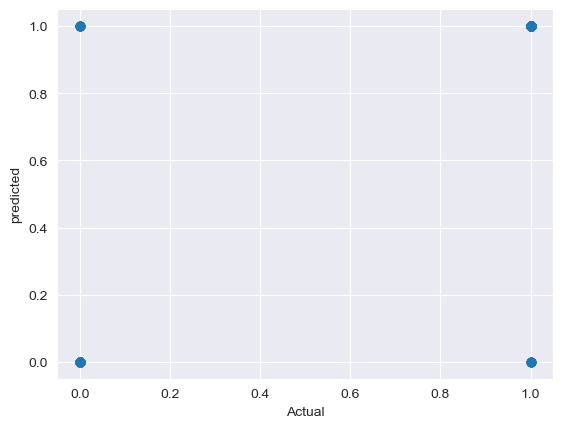

In [61]:
plt.scatter(y_train,y_train1_predict)
plt.xlabel('Actual')
plt.ylabel('predicted')
plt.show()

In [63]:
from sklearn.metrics import confusion_matrix

In [65]:
c_fk = confusion_matrix(y_test,y_lr_pred)
print(c_fk)

[[26  9]
 [ 5 21]]


In [67]:
c_fk1 = confusion_matrix(y_test,y_knn_pred)
print(c_fk1)

[[21 14]
 [ 4 22]]


In [69]:
c_fk2 = confusion_matrix(y_test,y_dt_pred)
print(c_fk2)

[[24 11]
 [ 4 22]]


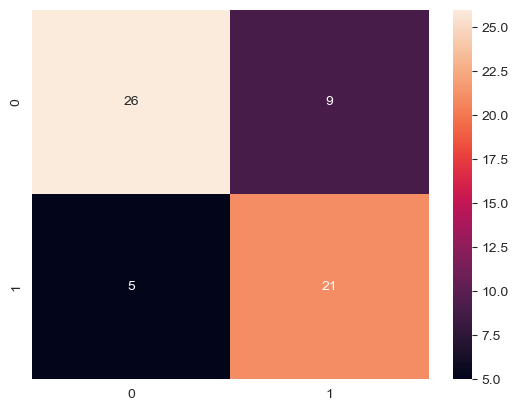

In [71]:
c = True
h = sns.heatmap(c_fk,annot = c, mask = False)
plt.show()

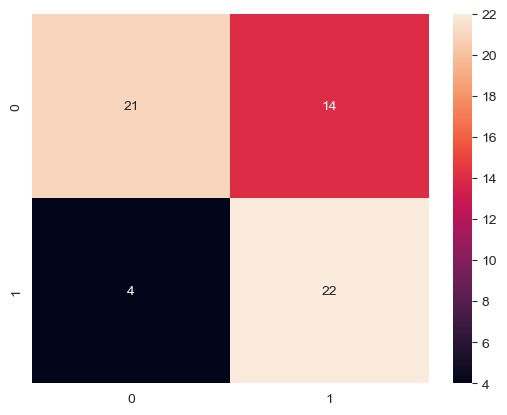

In [73]:
c = True
h = sns.heatmap(c_fk1,annot = c, mask = False)
plt.show()

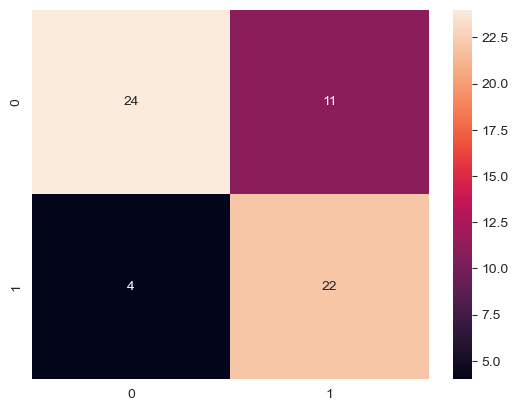

In [75]:
c = True
h = sns.heatmap(c_fk2,annot = c, mask = False)
plt.show()

In [77]:
c_f = confusion_matrix(y_train,y_train1_predict)
print(c_f)

[[ 82  21]
 [ 12 127]]


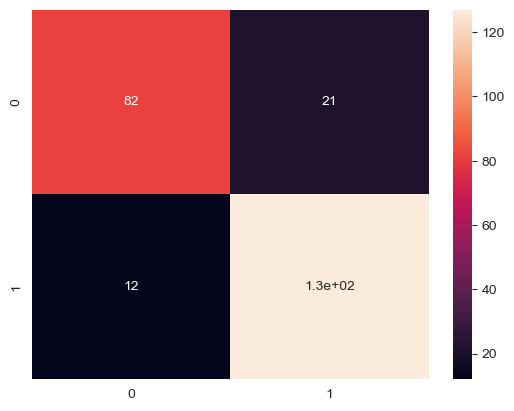

In [79]:
c = True
h = sns.heatmap(c_f,annot = c, mask = False)
plt.show()

In [85]:
c_f = confusion_matrix(y_train,y_train1_predict)
print(c_f)

[[ 82  21]
 [ 12 127]]


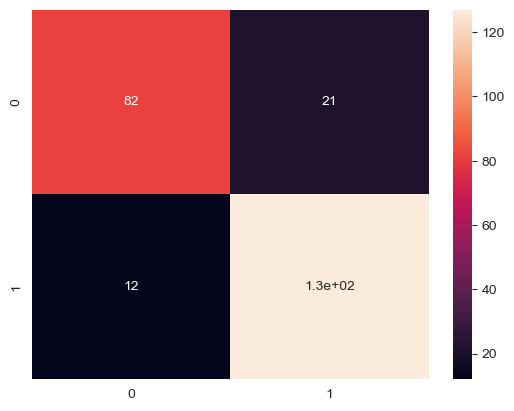

In [87]:
c = True
h = sns.heatmap(c_f,annot = c, mask = False)
plt.show()

In [89]:
y_test_predict = knn.predict(X_test)
print(y_test)
print(y_test_predict)

246    0
183    0
229    0
126    1
184    0
      ..
277    0
121    1
187    0
301    0
283    0
Name: target, Length: 61, dtype: int64
[1 1 1 1 0 1 1 1 1 0 1 0 0 1 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 0 1 0 0 1]


In [91]:
y_test1_predict = lr.predict(X_test)
print(y_test)
print(y_test1_predict)

246    0
183    0
229    0
126    1
184    0
      ..
277    0
121    1
187    0
301    0
283    0
Name: target, Length: 61, dtype: int64
[0 1 0 1 0 1 1 1 1 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 0 1
 0 1 0 0 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 0 0 1]


In [93]:
from sklearn.metrics import classification_report
d=classification_report(y_test,y_test_predict)
print(d)

              precision    recall  f1-score   support

           0       0.84      0.60      0.70        35
           1       0.61      0.85      0.71        26

    accuracy                           0.70        61
   macro avg       0.73      0.72      0.70        61
weighted avg       0.74      0.70      0.70        61



In [95]:
p = lr.predict([[18,1,3,105,155,1,0,90,0,3.0,1,1,2]])
print(p)

[0]


C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


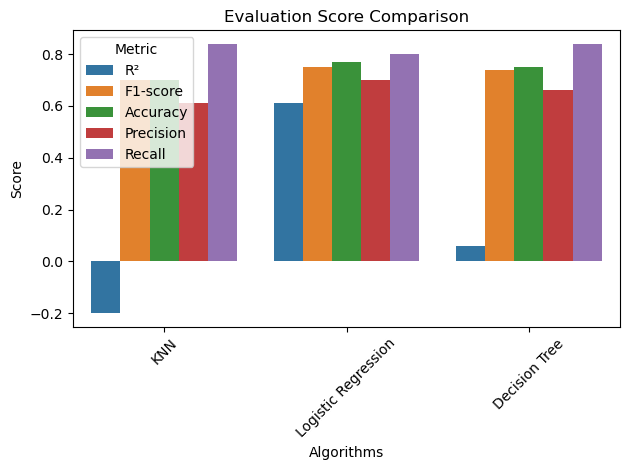

In [7]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt  # Optional for customization

# Sample data (replace with your actual scores)
data = {
    'algorithms': ["KNN", "Logistic Regression", "Decision Tree"],
    'R²': [-0.20, 0.61, 0.06],
    'F1-score': [0.70, 0.75, 0.74],
    'Accuracy': [0.70, 0.77, 0.75],
    'Precision': [0.61, 0.7, 0.66],
    'Recall': [0.84, 0.80, 0.84]
}

df = pd.DataFrame(data)  # Create a pandas dataframe

# Create a melted dataframe for plotting
df_melt = df.melt(id_vars='algorithms', var_name='Metric', value_name='Score')

# Create a bar chart with Seaborn
sns.barplot(x='algorithms', y='Score', hue='Metric', data=df_melt)

# Optional customizations using matplotlib (adjust as needed)
plt.xlabel('Algorithms')
plt.ylabel('Score')
plt.title('Evaluation Score Comparison')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()

plt.show()